# Análise exploratória do PPI

O notebook lê `ppi_daily` no snapshot `data/gas_flare.sqlite` e traça as quatro dimensões percentuais ao longo do tempo.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8')

cwd = Path.cwd().resolve()
if (cwd / 'src').is_dir() and (cwd / 'data').is_dir():
    project_root = cwd
elif (cwd.parent / 'src').is_dir() and (cwd.parent / 'data').is_dir():
    project_root = cwd.parent
else:
    raise FileNotFoundError(
        'Could not locate proj_IV root (expected src/ and data/). '
        'Open notebooks from proj_IV/ or proj_IV/notebooks/.'
    )

sys.path.insert(0, str(project_root / 'src'))

from db_access import read_engine, resolve_database_url

ENGINE = read_engine(project_root)
DATABASE_URL = resolve_database_url(project_root)
DATABASE_URL

'sqlite:///D:\\Users\\Ricardo\\Documents\\opencode\\proj_IV\\data\\gas_flare.sqlite'

In [2]:
query = '''
SELECT
    report_date,
    pbr_gas_R, pbr_gas_pct,
    pbr_die_R, pbr_die_pct,
    ind_gas_R, ind_gas_pct,
    ind_die_R, ind_die_pct
FROM ppi_daily
ORDER BY report_date
'''

df = pd.read_sql_query(query, ENGINE)

df['report_date'] = pd.to_datetime(df['report_date'], errors='coerce')
df = df.sort_values('report_date').reset_index(drop=True)

df.head()

,report_date,pbr_gas_R,pbr_gas_pct,pbr_die_R,pbr_die_pct,ind_gas_R,ind_gas_pct,ind_die_R,ind_die_pct
0,2022-01-05,-1.01,-3.0,1.02,3.0,NaN,NaN,NaN,NaN
1,2022-01-11,-0.07,-2.0,0.08,2.0,NaN,NaN,NaN,NaN
2,2022-01-18,-0.30,-9.0,0.01,0.0,NaN,NaN,NaN,NaN
3,2022-02-01,-0.28,-8.0,-0.37,-9.0,NaN,NaN,NaN,NaN
4,2022-02-02,-0.30,-9.0,-0.37,-9.0,NaN,NaN,NaN,NaN


In [3]:
print(f'Rows: {len(df):,}')
print(f'Columns: {df.shape[1]}')
print(f'Date range: {df["report_date"].min().date()} to {df["report_date"].max().date()}')

display(df.describe(include='all').T)

Rows: 1,126
Columns: 9
Date range: 2022-01-05 to 2026-08-14


,count,mean,min,25%,50%,75%,max,std
report_date,1126,2024-05-12 01:15:27.175843,2022-01-05 00:00:00,2023-03-27 06:00:00,2024-05-15 12:00:00,2025-07-06 06:00:00,2026-08-14 00:00:00,NaN
pbr_gas_R,1126.0,-0.24762,-13.0,-0.36,-0.13,0.05,0.54,0.591299
pbr_gas_pct,1126.0,-7.897869,-88.0,-11.0,-4.0,2.0,21.0,16.783835
pbr_die_R,1126.0,-0.40033,-11.0,-0.51,-0.25,-0.06,1.19,0.665287
pbr_die_pct,1126.0,-10.492007,-86.0,-13.0,-7.0,-2.0,19.0,16.279651
ind_gas_R,940.0,-0.194106,-1.98,-0.29,-0.1,0.06,0.48,0.399728
ind_gas_pct,940.0,-6.989362,-77.0,-9.0,-3.0,2.0,19.0,15.254738
ind_die_R,940.0,-0.350191,-2.75,-0.45,-0.23,-0.06,0.64,0.500701
ind_die_pct,940.0,-9.873404,-78.0,-12.0,-6.0,-2.0,17.0,14.480126


In [4]:
missing = df.isna().sum().sort_values(ascending=False).to_frame('missing_count')
missing['missing_pct'] = (missing['missing_count'] / len(df) * 100).round(2)
missing

,missing_count,missing_pct
ind_die_pct,186,16.52
ind_gas_pct,186,16.52
ind_die_R,186,16.52
ind_gas_R,186,16.52
report_date,0,0.00
pbr_die_pct,0,0.00
pbr_die_R,0,0.00
pbr_gas_pct,0,0.00
pbr_gas_R,0,0.00


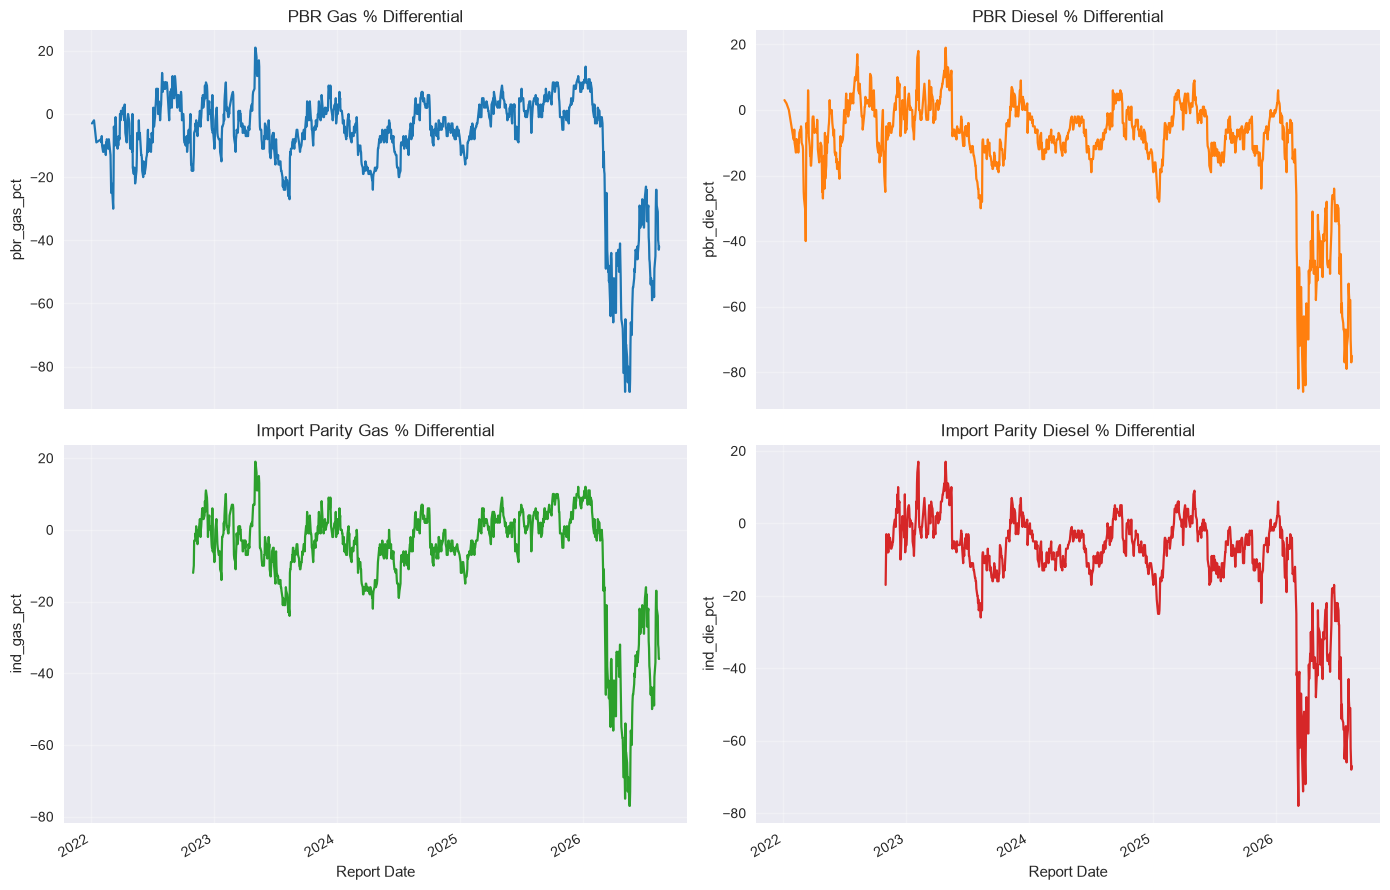

In [5]:
series_map = [
    ('pbr_gas_pct', 'PBR Gas % Differential', '#1f77b4'),
    ('pbr_die_pct', 'PBR Diesel % Differential', '#ff7f0e'),
    ('ind_gas_pct', 'Import Parity Gas % Differential', '#2ca02c'),
    ('ind_die_pct', 'Import Parity Diesel % Differential', '#d62728'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.ravel()

for ax, (col, title, color) in zip(axes, series_map):
    plot_df = df[['report_date', col]].dropna()
    ax.plot(plot_df['report_date'], plot_df[col], linewidth=1.6, color=color)
    ax.set_title(title)
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

for ax in axes[2:]:
    ax.set_xlabel('Report Date')

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

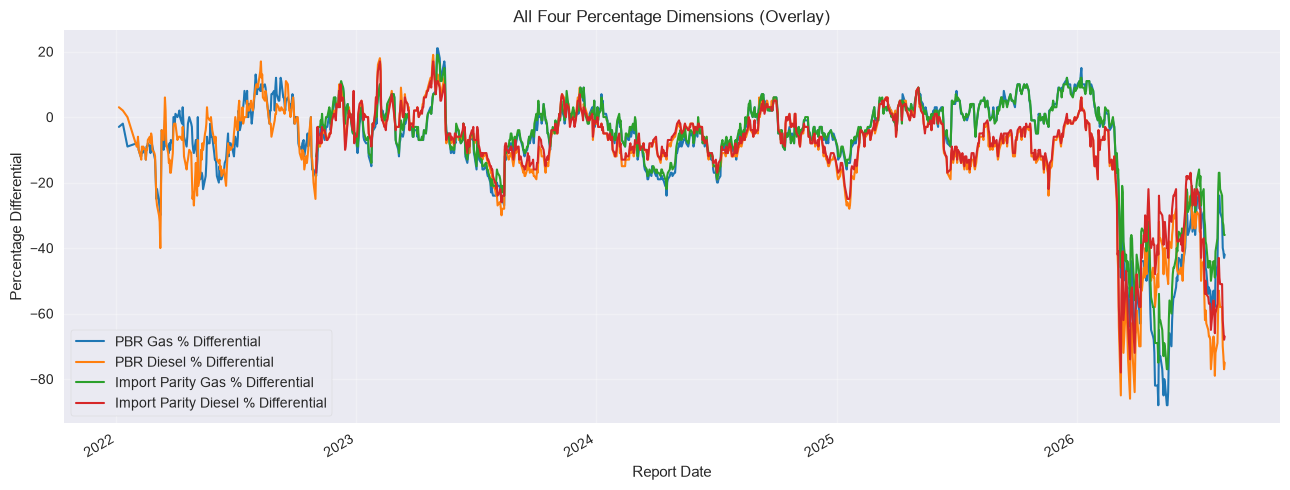

In [6]:
fig, ax = plt.subplots(figsize=(13, 5))

for col, title, color in series_map:
    plot_df = df[['report_date', col]].dropna()
    ax.plot(plot_df['report_date'], plot_df[col], label=title, linewidth=1.5, color=color)

ax.set_title('All Four Percentage Dimensions (Overlay)')
ax.set_xlabel('Report Date')
ax.set_ylabel('Percentage Differential')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', frameon=True)
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

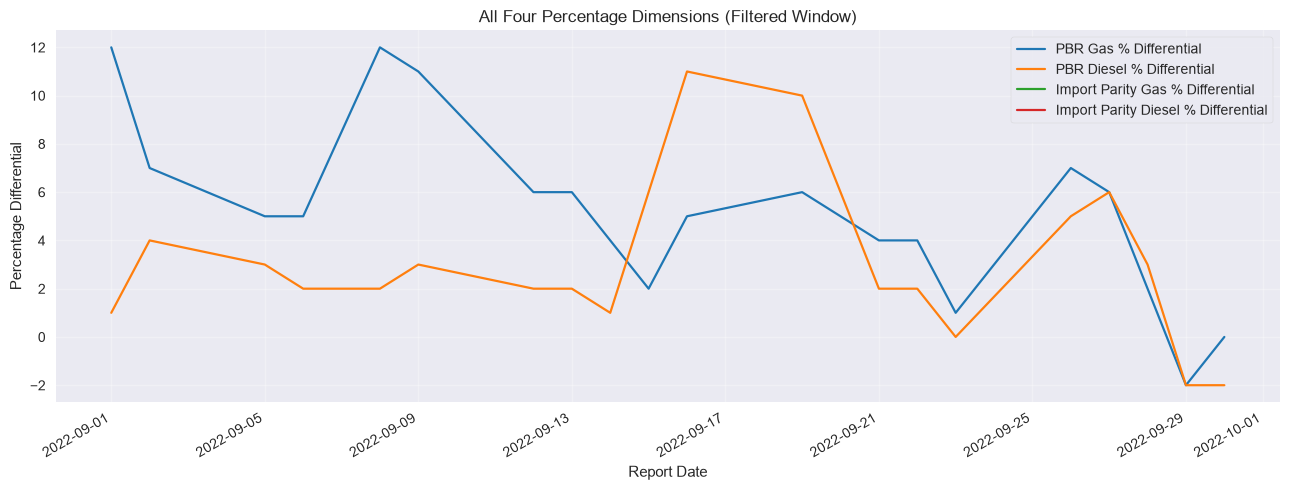

In [7]:
# Set date limits (YYYY-MM-DD). Use None for full range.
start_date = '2022-09-01'
end_date = '2022-10-01'

filtered_df = df.copy()
if start_date is not None:
    filtered_df = filtered_df[filtered_df['report_date'] >= pd.to_datetime(start_date)]
if end_date is not None:
    filtered_df = filtered_df[filtered_df['report_date'] <= pd.to_datetime(end_date)]

fig, ax = plt.subplots(figsize=(13, 5))
for col, title, color in series_map:
    plot_df = filtered_df[['report_date', col]].dropna()
    ax.plot(plot_df['report_date'], plot_df[col], label=title, linewidth=1.6, color=color)

ax.set_title('All Four Percentage Dimensions (Filtered Window)')
ax.set_xlabel('Report Date')
ax.set_ylabel('Percentage Differential')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', frameon=True)
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()